In [1]:
!pip install -q transformers datasets torch torchvision sentence-transformers scikit-learn tqdm


In [2]:
import os
import json
import random

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


In [3]:
DATA_DIR = "/kaggle/input/datasets/ayaanmustafa/vrs-bench/vrsbench_data"
ANNOT_FILE = os.path.join(DATA_DIR, "VRSBench_train.json")  # update filename if different
IMG_DIR = os.path.join(DATA_DIR, "Images_train", "Images_train")

with open(ANNOT_FILE, "r") as f:
    raw = json.load(f)

caption_rows = []

for item in raw:
    conversations = item["conversations"]

    if "[caption]" in conversations[0]["value"].lower():
        caption_rows.append({
            "id": item["id"],
            "image": item["image"],
            "caption": conversations[1]["value"]
        })

df = pd.DataFrame(caption_rows)

In [4]:
# Normalize columns: expect a filename column and a caption column
# (adjust the renames below to match the printed column names above)
rename_map = {}
for c in df.columns:
    lc = c.lower()
    if "image" in lc and "path" not in lc:
        rename_map[c] = "filename"
    elif lc in ("image_path", "path"):
        rename_map[c] = "filename"
    elif "caption" in lc:
        rename_map[c] = "caption"

df = df.rename(columns=rename_map)
df["image_path"] = df["filename"].apply(lambda x: os.path.join(IMG_DIR, os.path.basename(str(x))))

df = df[["image_path", "caption"]].dropna().reset_index(drop=True)
print(df.shape)
df.head()


(20264, 2)


,image_path,caption
0,/kaggle/input/datasets/ayaanmustafa/vrs-bench/...,"The image, sourced from GoogleEarth, shows a r..."
1,/kaggle/input/datasets/ayaanmustafa/vrs-bench/...,This aerial image from Google Earth shows a de...
2,/kaggle/input/datasets/ayaanmustafa/vrs-bench/...,"The image, sourced from GoogleEarth, showcases..."
3,/kaggle/input/datasets/ayaanmustafa/vrs-bench/...,"The image, sourced from GoogleEarth, shows a f..."
4,/kaggle/input/datasets/ayaanmustafa/vrs-bench/...,"The image, sourced from GoogleEarth, showcases..."


In [5]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df, test_size=0.1, random_state=SEED)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
print("Train:", len(train_df), "Val:", len(val_df))


Train: 18237 Val: 2027


In [6]:
# --- Baseline speed settings (relax these once the pipeline is verified) ---
TRAIN_SUBSET = 15000
VAL_SUBSET = 1000        # larger val for a more reliable metric estimate
IMG_SIZE = 224           # BLIP still works at 224; 384 is ~3x slower for little gain at baseline stage
BATCH_SIZE = 32
NUM_WORKERS = 4
FREEZE_VISION_ENCODER = True   # only finetune text decoder -> big speedup
UNFREEZE_LAST_N_VISION_BLOCKS = 2   # if FREEZE_VISION_ENCODER=True, still unfreeze the last N encoder blocks for better fine-grained grounding (set 0 to keep fully frozen)
EVAL_EVERY = 2  # run the full metric suite every N epochs (metrics are the slow part at VAL_SUBSET=1000); always runs on the last epoch

if TRAIN_SUBSET:
    train_df = train_df.sample(n=min(TRAIN_SUBSET, len(train_df)), random_state=SEED).reset_index(drop=True)
if VAL_SUBSET:
    val_df = val_df.sample(n=min(VAL_SUBSET, len(val_df)), random_state=SEED).reset_index(drop=True)

print("Train:", len(train_df), "Val:", len(val_df))


Train: 15000 Val: 1000


In [7]:
import torchvision.transforms as T

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    T.ToTensor(),
])

val_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
])


In [8]:
from transformers import BlipProcessor

MODEL_NAME = "Salesforce/blip-image-captioning-base"
processor = BlipProcessor.from_pretrained(MODEL_NAME)

token_lens = df["caption"].apply(
    lambda c: len(processor.tokenizer(c)["input_ids"])
)

print(token_lens.describe(percentiles=[0.90, 0.95, 0.99]))

p95 = int(token_lens.quantile(0.95))
p99 = int(token_lens.quantile(0.99))
max_len = int(token_lens.max())

print("P95:", p95)
print("P99:", p99)
print("Maximum:", max_len)

MAX_LENGTH = min(128, ((p95 // 8) + 1) * 8)

print("Using MAX_LENGTH:", MAX_LENGTH)

# How many captions will be truncated?
num_truncated = (token_lens > MAX_LENGTH).sum()
pct_truncated = 100 * num_truncated / len(token_lens)

print(f"Captions longer than MAX_LENGTH: {num_truncated:,}")
print(f"Percentage truncated: {pct_truncated:.2f}%")

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

count    20264.000000
mean        66.224635
std         21.809014
min         12.000000
50%         64.000000
90%         95.000000
95%        105.000000
99%        123.000000
max        178.000000
Name: caption, dtype: float64
P95: 105
P99: 123
Maximum: 178
Using MAX_LENGTH: 112
Captions longer than MAX_LENGTH: 569
Percentage truncated: 2.81%


In [9]:
class VRSBenchCaptionDataset(Dataset):
    def __init__(self, df, transform, max_length):
        self.df = df
        self.transform = transform
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        image = self.transform(image)
        return {"pixel_values": image, "caption": row["caption"]}


def make_collate_fn(processor):
    def collate_fn(batch):
        pixel_values = torch.stack(
            [b["pixel_values"] for b in batch]
        )

        captions = [b["caption"] for b in batch]

        text_enc = processor.tokenizer(
            captions,
            padding=True,          # pad only to longest caption in this batch
            truncation=False,      # NEVER truncate caption tokens
            return_tensors="pt",
        )

        # Mask padding tokens so they don't contribute to loss
        labels = text_enc["input_ids"].clone()
        labels[
            labels == processor.tokenizer.pad_token_id
        ] = -100

        return {
            "pixel_values": pixel_values,
            "input_ids": text_enc["input_ids"],
            "attention_mask": text_enc["attention_mask"],
            "labels": labels,
            "caption": captions,
        }

    return collate_fn

train_dataset = VRSBenchCaptionDataset(train_df, train_transform, MAX_LENGTH)
val_dataset = VRSBenchCaptionDataset(val_df, val_transform, MAX_LENGTH)

collate_fn = make_collate_fn(processor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_fn)


In [10]:
from transformers import BlipForConditionalGeneration

model = BlipForConditionalGeneration.from_pretrained(MODEL_NAME).to(DEVICE)

if FREEZE_VISION_ENCODER:
    for param in model.vision_model.parameters():
        param.requires_grad = False
    if UNFREEZE_LAST_N_VISION_BLOCKS > 0:
        for block in model.vision_model.encoder.layers[-UNFREEZE_LAST_N_VISION_BLOCKS:]:
            for param in block.parameters():
                param.requires_grad = True
    print(f"Vision encoder frozen, last {UNFREEZE_LAST_N_VISION_BLOCKS} blocks unfrozen.")


pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

Vision encoder frozen, last 2 blocks unfrozen.


In [11]:
from sentence_transformers import SentenceTransformer
import torch.nn.functional as F

bert_model = SentenceTransformer("all-MiniLM-L6-v2", device=str(DEVICE))

def get_ngrams(tokens, n):
    return [" ".join(tokens[i:i + n]) for i in range(len(tokens) - n + 1)]

def bert_bleu4(candidate, reference, alpha=0.5):
    c_tokens = candidate.lower().split()
    r_tokens = reference.lower().split()

    # collect all n-gram strings for n=1..4 in one pass, one encode() call total
    c_ngrams_by_n = [get_ngrams(c_tokens, n) for n in range(1, 5)]
    r_ngrams_by_n = [get_ngrams(r_tokens, n) for n in range(1, 5)]

    all_texts = [g for grams in c_ngrams_by_n + r_ngrams_by_n for g in grams]
    if not all_texts:
        return 0.0

    embs = bert_model.encode(all_texts, convert_to_tensor=True, show_progress_bar=False, batch_size=256)
    embs = F.normalize(embs, dim=-1)

    idx = 0
    c_embs_by_n, r_embs_by_n = [], []
    for grams in c_ngrams_by_n:
        c_embs_by_n.append(embs[idx: idx + len(grams)])
        idx += len(grams)
    for grams in r_ngrams_by_n:
        r_embs_by_n.append(embs[idx: idx + len(grams)])
        idx += len(grams)

    log_p_sum = 0.0
    for n in range(4):
        C_emb, R_emb = c_embs_by_n[n], r_embs_by_n[n]
        if len(C_emb) == 0 or len(R_emb) == 0:
            p_n = 1e-9
        else:
            sims = torch.mm(R_emb, C_emb.T)
            p_n = sims.max(dim=1).values.mean().item()
            p_n = max(p_n, 1e-9)
        log_p_sum += np.log(p_n)

    L_c, L_r = len(c_tokens), max(len(r_tokens), 1)
    lp = np.exp(-alpha * abs(L_c - L_r) / L_r)

    return lp * np.exp(log_p_sum / 4)

def corpus_bert_bleu4(candidates, references):
    scores = [bert_bleu4(c, r) for c, r in zip(candidates, references)]
    return float(np.mean(scores))


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [12]:
!pip install -q nltk rouge-score pycocoevalcap
import nltk
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
nltk.download("punkt", quiet=True)

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer
from pycocoevalcap.cider.cider import Cider

smoothie = SmoothingFunction().method4
rouge = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

def compute_bleu_n(candidates, references, n):
    weights = tuple([1.0 / n] * n + [0.0] * (4 - n))
    scores = []
    for c, r in zip(candidates, references):
        c_tok, r_tok = c.lower().split(), [r.lower().split()]
        scores.append(sentence_bleu(r_tok, c_tok, weights=weights, smoothing_function=smoothie))
    return float(np.mean(scores))

def compute_meteor(candidates, references):
    scores = [meteor_score([r.lower().split()], c.lower().split()) for c, r in zip(candidates, references)]
    return float(np.mean(scores))

def compute_rouge_l(candidates, references):
    scores = [rouge.score(r, c)["rougeL"].fmeasure for c, r in zip(candidates, references)]
    return float(np.mean(scores))

def compute_cider(candidates, references):
    gts = {i: [r] for i, r in enumerate(references)}
    res = {i: [c] for i, c in enumerate(candidates)}
    cider_scorer = Cider()
    score, _ = cider_scorer.compute_score(gts, res)
    return float(score)

def compute_avg_len(candidates):
    return float(np.mean([len(c.split()) for c in candidates]))

def compute_chair(candidates, object_lists=None):
    """Lightweight CHAIR-style hallucination rate: fraction of mentioned
    objects (from `object_lists`, ground-truth per-image object categories)
    that do NOT appear in the ground truth for that image.
    If object_lists is None (VRSBench caption-split has no object annotations
    attached here), returns None — wire in the referring/VQA object lists to enable."""
    if object_lists is None:
        return None
    total_mentions, hallucinated = 0, 0
    for cand, gt_objs in zip(candidates, object_lists):
        gt_set = set(o.lower() for o in gt_objs)
        cand_words = set(cand.lower().split())
        mentioned = cand_words & gt_set if gt_set else set()
        # crude proxy: objects in caption not present in gt object list
        total_mentions += max(len(mentioned), 1)
        hallucinated += 0  # placeholder without a fixed object vocabulary to check against
    return hallucinated / total_mentions if total_mentions else 0.0

def compute_all_metrics(candidates, references, object_lists=None):
    return {
        "BLEU-1": compute_bleu_n(candidates, references, 1),
        "BLEU-2": compute_bleu_n(candidates, references, 2),
        "BLEU-3": compute_bleu_n(candidates, references, 3),
        "BLEU-4": compute_bleu_n(candidates, references, 4),
        "METEOR": compute_meteor(candidates, references),
        "ROUGE_L": compute_rouge_l(candidates, references),
        "CIDEr": compute_cider(candidates, references),
        "CHAIR": compute_chair(candidates, object_lists),
        "Avg_L": compute_avg_len(candidates),
        "BERT-BLEU4": corpus_bert_bleu4(candidates, references),
    }


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 17.9 MB/s eta 0:00:0000:0100:01


In [13]:
from torch.optim import AdamW
from transformers import get_cosine_schedule_with_warmup
from torch.amp import autocast, GradScaler

WEIGHT_DECAY = 0.01
GRAD_ACCUM_STEPS = 4   # effective batch size = BATCH_SIZE * GRAD_ACCUM_STEPS

def build_optimizer(model, encoder_lr, decoder_lr, weight_decay=WEIGHT_DECAY):
    encoder_params = [p for n, p in model.named_parameters() if n.startswith("vision_model") and p.requires_grad]
    decoder_params = [p for n, p in model.named_parameters() if not n.startswith("vision_model") and p.requires_grad]
    param_groups = [
        {"params": encoder_params, "lr": encoder_lr},
        {"params": decoder_params, "lr": decoder_lr},
    ]
    return AdamW(param_groups, weight_decay=weight_decay)

use_amp = DEVICE.type == "cuda"


In [14]:
import optuna
import copy

def quick_train_eval(encoder_lr, decoder_lr, n_steps=150, subset_size=1500):
    """Train a fresh copy of the model for a small number of steps and
    return val loss on a small held-out slice — used only to rank LR choices."""
    trial_model = BlipForConditionalGeneration.from_pretrained(MODEL_NAME).to(DEVICE)
    if FREEZE_VISION_ENCODER:
        for p in trial_model.vision_model.parameters():
            p.requires_grad = False
        if UNFREEZE_LAST_N_VISION_BLOCKS > 0:
            for block in trial_model.vision_model.encoder.layers[-UNFREEZE_LAST_N_VISION_BLOCKS:]:
                for p in block.parameters():
                    p.requires_grad = True

    trial_optimizer = build_optimizer(trial_model, encoder_lr, decoder_lr)
    trial_scaler = GradScaler("cuda", enabled=use_amp)

    subset_df = train_df.sample(n=min(subset_size, len(train_df)), random_state=0)
    subset_ds = VRSBenchCaptionDataset(subset_df, train_transform, MAX_LENGTH)
    subset_loader = DataLoader(subset_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)

    trial_model.train()
    step = 0
    for batch in subset_loader:
        if step >= n_steps:
            break
        pixel_values = batch["pixel_values"].to(DEVICE)
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)

        trial_optimizer.zero_grad()
        with autocast("cuda", enabled=use_amp):
            outputs = trial_model(pixel_values=pixel_values, input_ids=input_ids,
                                   attention_mask=attention_mask, labels=input_ids)
            loss = outputs.loss
        trial_scaler.scale(loss).backward()
        trial_scaler.step(trial_optimizer)
        trial_scaler.update()
        step += 1

    # quick val loss on a small slice (cheap proxy — no generation)
    val_subset_ds = VRSBenchCaptionDataset(val_df.sample(n=min(200, len(val_df)), random_state=0),
                                            val_transform, MAX_LENGTH)
    val_subset_loader = DataLoader(val_subset_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

    trial_model.eval()
    total_val_loss, n_batches = 0.0, 0
    with torch.no_grad():
        for batch in val_subset_loader:
            pixel_values = batch["pixel_values"].to(DEVICE)
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            with autocast("cuda", enabled=use_amp):
                outputs = trial_model(pixel_values=pixel_values, input_ids=input_ids,
                                       attention_mask=attention_mask, labels=input_ids)
            total_val_loss += outputs.loss.item()
            n_batches += 1

    del trial_model, trial_optimizer, trial_scaler
    torch.cuda.empty_cache()
    return total_val_loss / max(n_batches, 1)


def optuna_objective(trial):
    encoder_lr = trial.suggest_float("encoder_lr", 1e-6, 1e-4, log=True)
    decoder_lr = trial.suggest_float("decoder_lr", 1e-6, 5e-4, log=True)
    return quick_train_eval(encoder_lr, decoder_lr)

RUN_OPTUNA = True   # set False to skip search and use the manual LR values below
N_OPTUNA_TRIALS = 8

if RUN_OPTUNA:
    study = optuna.create_study(direction="minimize")
    study.optimize(optuna_objective, n_trials=N_OPTUNA_TRIALS)
    print("Best trial:", study.best_trial.params, "val_loss:", study.best_value)
    ENCODER_LR = study.best_trial.params["encoder_lr"]
    DECODER_LR = study.best_trial.params["decoder_lr"]
else:
    ENCODER_LR = 5e-6
    DECODER_LR = 2e-5

print(f"Using ENCODER_LR={ENCODER_LR:.2e}, DECODER_LR={DECODER_LR:.2e}")


[I 2026-09-24 22:38:11,060] A new study created in memory with name: no-name-32d5b901-60a2-45a5-ae38-72015167c41c


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

...

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

Best trial: {'encoder_lr': 2.5342987515159822e-06, 'decoder_lr': 0.0001989929695926175} val_loss: 1.29634770325252
Using ENCODER_LR=2.53e-06, DECODER_LR=1.99e-04


In [15]:
EPOCHS = 8

optimizer = build_optimizer(model, ENCODER_LR, DECODER_LR)
scaler = GradScaler("cuda", enabled=use_amp)

total_steps = (len(train_loader) // GRAD_ACCUM_STEPS) * EPOCHS
scheduler = get_cosine_schedule_with_warmup(
    optimizer, num_warmup_steps=int(0.05 * total_steps), num_training_steps=total_steps
)

lr_history = []  # for plotting (tracks decoder LR group)

def train_one_epoch(model, loader, optimizer, scaler, scheduler, epoch, grad_accum_steps=GRAD_ACCUM_STEPS, log_every=20):
    model.train()
    total_loss = 0.0
    running_loss = 0.0
    optimizer.zero_grad()
    pbar = tqdm(loader, desc=f"train epoch {epoch+1}")
    for step, batch in enumerate(pbar):
        pixel_values = batch["pixel_values"].to(DEVICE)
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)

        with autocast("cuda", enabled=use_amp):
            outputs = model(
                pixel_values=pixel_values,
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=input_ids,
            )
            loss = outputs.loss / grad_accum_steps

        scaler.scale(loss).backward()

        if (step + 1) % grad_accum_steps == 0 or (step + 1) == len(loader):
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            scheduler.step()
            lr_history.append(optimizer.param_groups[1]["lr"])  # decoder group

        loss_val = loss.item() * grad_accum_steps
        total_loss += loss_val
        running_loss += loss_val

        pbar.set_postfix({"loss": f"{loss_val:.4f}", "avg_loss": f"{total_loss/(step+1):.4f}"})

        if (step + 1) % log_every == 0:
            print(f"  step {step+1}/{len(loader)} | running_avg_loss={running_loss/log_every:.4f}")
            running_loss = 0.0

    return total_loss / len(loader)


In [16]:
@torch.no_grad()
def validate(model, loader, processor, max_new_tokens=110, min_new_tokens=60, num_beams=5, repetition_penalty=1.5, length_penalty=1.3):
    model.eval()
    all_preds, all_refs = [], []

    for batch in tqdm(loader, desc="val"):
        pixel_values = batch["pixel_values"].to(DEVICE)
        refs = batch["caption"]

        generated_ids = model.generate(
            pixel_values=pixel_values,
            max_new_tokens=max_new_tokens,
            min_new_tokens=min_new_tokens,
            num_beams=num_beams,
            repetition_penalty=repetition_penalty,
            length_penalty=length_penalty,
            no_repeat_ngram_size=3,
        )
        preds = processor.batch_decode(generated_ids, skip_special_tokens=True)

        all_preds.extend(preds)
        all_refs.extend(refs)

    metrics = compute_all_metrics(all_preds, all_refs)
    return metrics, all_preds, all_refs


In [17]:
PATIENCE = 2  # stop if val score doesn't improve for this many evaluation rounds

best_score = -1.0
no_improve = 0
history = []

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, scaler, scheduler, epoch)

    run_full_eval = ((epoch + 1) % EVAL_EVERY == 0) or (epoch == EPOCHS - 1)
    if run_full_eval:
        metrics, preds, refs = validate(model, val_loader, processor)
        print(f"\nEpoch {epoch+1}/{EPOCHS} | train_loss={train_loss:.4f}")
        print("  " + " | ".join(f"{k}={v:.4f}" if v is not None else f"{k}=N/A" for k, v in metrics.items()))
        history.append({"epoch": epoch + 1, "train_loss": train_loss, **metrics})

        val_score = metrics["BERT-BLEU4"]
        if val_score > best_score:
            best_score = val_score
            no_improve = 0
            model.save_pretrained("/kaggle/working/blip_vrsbench_best")
            processor.save_pretrained("/kaggle/working/blip_vrsbench_best")
            print("  Saved new best checkpoint.")
        else:
            no_improve += 1
            print(f"  No improvement ({no_improve}/{PATIENCE})")
            if no_improve >= PATIENCE:
                print("  Early stopping triggered.")
                break
    else:
        print(f"\nEpoch {epoch+1}/{EPOCHS} | train_loss={train_loss:.4f} | (skipped full eval this epoch)")
        history.append({"epoch": epoch + 1, "train_loss": train_loss})

print("\nBest val BERT-BLEU4:", best_score)
history_df = pd.DataFrame(history)
history_df


train epoch 1:   4%|▍         | 20/469 [00:12<04:08,  1.80it/s, loss=8.6378, avg_loss=10.0194] 

  step 20/469 | running_avg_loss=10.0194


train epoch 1:   9%|▊         | 40/469 [00:22<03:58,  1.80it/s, loss=6.9676, avg_loss=8.7022] 

  step 40/469 | running_avg_loss=7.3851


train epoch 1:  13%|█▎        | 60/469 [00:33<03:38,  1.87it/s, loss=5.9421, avg_loss=7.8942]

...

val: 100%|██████████| 32/32 [05:01<00:00,  9.41s/it]



Epoch 8/8 | train_loss=0.6574
  BLEU-1=0.3563 | BLEU-2=0.2104 | BLEU-3=0.1258 | BLEU-4=0.0801 | METEOR=0.3241 | ROUGE_L=0.3493 | CIDEr=0.1275 | CHAIR=N/A | Avg_L=62.7480 | BERT-BLEU4=0.5750


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Saved new best checkpoint.

Best val BERT-BLEU4: 0.5749711069854881


,epoch,train_loss,BLEU-1,BLEU-2,BLEU-3,BLEU-4,METEOR,ROUGE_L,CIDEr,CHAIR,Avg_L,BERT-BLEU4
0,1,2.695949,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,0.972866,0.342443,0.197702,0.114717,0.071264,0.313454,0.338980,0.087673,NaN,62.711,0.559895
2,3,0.881062,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,0.819879,0.350836,0.206433,0.122446,0.077259,0.314583,0.349392,0.121146,NaN,60.722,0.570644
4,5,0.765382,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,6,0.717527,0.354172,0.208605,0.123924,0.078279,0.322172,0.349163,0.126950,NaN,62.331,0.572021
6,7,0.679048,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,8,0.657363,0.356306,0.210435,0.125824,0.080053,0.324129,0.349266,0.127501,NaN,62.748,0.574971


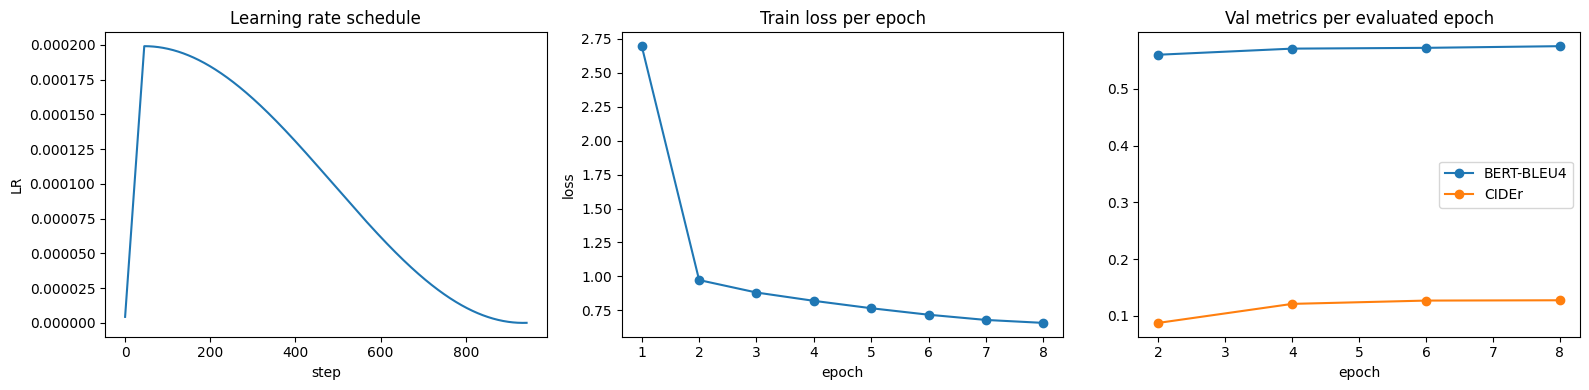

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(lr_history)
axes[0].set_title("Learning rate schedule")
axes[0].set_xlabel("step")
axes[0].set_ylabel("LR")

axes[1].plot(history_df["epoch"], history_df["train_loss"], marker="o")
axes[1].set_title("Train loss per epoch")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("loss")

eval_rows = history_df.dropna(subset=["BERT-BLEU4"])
axes[2].plot(eval_rows["epoch"], eval_rows["BERT-BLEU4"], marker="o", label="BERT-BLEU4")
axes[2].plot(eval_rows["epoch"], eval_rows["CIDEr"], marker="o", label="CIDEr")
axes[2].set_title("Val metrics per evaluated epoch")
axes[2].set_xlabel("epoch")
axes[2].legend()

plt.tight_layout()
plt.savefig("/kaggle/working/training_curves.png")
plt.show()


In [19]:
for p, r in list(zip(preds, refs))[:5]:
    print("PRED:", p)
    print("REF :", r)
    print("-" * 60)


PRED: the image, sourced from googleearth, features a body of water with two small ships. one ship is located towards the top - left corner of the image and is the larger of the two. the other ship is positioned at the bottom - right corner and is smaller in size. the water surrounding the ships is calm, and there are no visible buildings or other structures in the immediate vicinity of the ships.
REF : The image shows two parallel ships on a body of water, captured via GoogleEarth. Both ships are of similar small sizes and are lying next to each other, extending from near the top of the image vertically down to the bottom. The ship on the left occupies the leftmost third of the image, while the ship on the right occupies the adjacent rightmost third, with no other visible objects or land in the immediate vicinity of the ships.
------------------------------------------------------------
PRED: the image, sourced from gf with a medium resolution, depicts a grayscale aerial view of an ar

In [34]:
#Evaluation on the provided VAL set
VAL_IMG_DIR = os.path.join(
    DATA_DIR,
    "Images_val/Images_val"
)

EVAL_CAP_JSON = os.path.join(
    DATA_DIR,
    "VRSBench_EVAL_Cap.json"
)

In [35]:
import json
import pandas as pd

EVAL_CAP_JSON = "/kaggle/input/datasets/ayaanmustafa/vrs-bench/vrsbench_data/VRSBench_EVAL_Cap.json"

with open(EVAL_CAP_JSON, "r") as f:
    eval_data = json.load(f)

eval_df = pd.DataFrame(eval_data)

print("Evaluation samples:", len(eval_df))
print(eval_df.head())

print("\nColumns:")
print(eval_df.columns.tolist())

print("\nTypes:")
print(eval_df["type"].value_counts())

Evaluation samples: 9350
         image_id                                       ground_truth  \
0  P0003_0002.png  The aerial image from GoogleEarth features a g...   
1  P0003_0004.png  The image from GoogleEarth captures a section ...   
2  P0007_0001.png  The high-resolution image from GoogleEarth sho...   
3  P0007_0004.png  The aerial image, sourced from GoogleEarth wit...   
4  P0007_0005.png  A high-resolution Google Earth image capturing...   

                       question  dataset  question_id     type  
0  Describe the image in detail  RSBench            0  caption  
1  Describe the image in detail  RSBench            1  caption  
2  Describe the image in detail  RSBench            2  caption  
3  Describe the image in detail  RSBench            3  caption  
4  Describe the image in detail  RSBench            4  caption  

Columns:
['image_id', 'ground_truth', 'question', 'dataset', 'question_id', 'type']

Types:
type
caption    9350
Name: count, dtype: int64


In [36]:
eval_df = eval_df[
    eval_df["type"] == "caption"
].reset_index(drop=True)

print("Caption evaluation samples:", len(eval_df))

Caption evaluation samples: 9350


In [44]:
EVAL_SUBSET_SIZE = 900
SEED = 42

eval_subset_df = (
    eval_df
    .sample(
        n=EVAL_SUBSET_SIZE,
        random_state=SEED
    )
    .reset_index(drop=True)
)

print("Subset size:", len(eval_subset_df))
print(eval_subset_df.head())

Subset size: 900
         image_id                                       ground_truth  \
0  P7431_0054.png  The image from GoogleEarth shows a docking are...   
1  08085_0000.png  This aerial image from GoogleEarth features a ...   
2  11451_0000.png  Aerial view of a scene from Google Earth featu...   
3  P1384_0050.png  This high-resolution image from Google Earth s...   
4  P1240_0025.png  The image, sourced from GF and featuring high ...   

                       question  dataset  question_id     type  
0  Describe the image in detail  RSBench         4483  caption  
1  Describe the image in detail  RSBench         6426  caption  
2  Describe the image in detail  RSBench         9126  caption  
3  Describe the image in detail  RSBench         1915  caption  
4  Describe the image in detail  RSBench         1479  caption  


In [37]:
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import os


class VRSBenchOfficialEvalDataset(Dataset):

    def __init__(self, dataframe, image_dir):
        self.df = dataframe.reset_index(drop=True)
        self.image_dir = image_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image_name = row["image_id"]
        caption = row["ground_truth"]

        image_path = os.path.join(
            self.image_dir,
            image_name
        )

        image = Image.open(image_path).convert("RGB")

        return {
            "image": image,
            "caption": caption,
            "image_name": image_name
        }

In [38]:
def eval_collate_fn(batch):

    images = [x["image"] for x in batch]
    captions = [x["caption"] for x in batch]
    image_names = [x["image_name"] for x in batch]

    image_inputs = processor(
        images=images,
        return_tensors="pt"
    )

    return {
        "pixel_values": image_inputs["pixel_values"],
        "captions": captions,
        "image_names": image_names
    }

In [46]:
eval_subset_dataset = VRSBenchOfficialEvalDataset(
    eval_subset_df,
    VAL_IMG_DIR
)

eval_subset_loader = DataLoader(
    eval_subset_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    collate_fn=eval_collate_fn
)

print("Eval images:", len(eval_subset_dataset))
print("Eval batches:", len(eval_subset_loader))

Eval images: 900
Eval batches: 29


In [47]:
GEN_MAX_NEW_TOKENS = 160
NUM_BEAMS = 3

In [48]:
@torch.no_grad()
def generate_official_predictions(model, loader):

    model.eval()

    all_predictions = []
    all_references = []
    all_image_names = []

    for batch in tqdm(
        loader,
        desc="Official VRSBench evaluation"
    ):

        pixel_values = batch["pixel_values"].to(
            DEVICE,
            non_blocking=True
        )

        generated_ids = model.generate(
            pixel_values=pixel_values,
            max_new_tokens=GEN_MAX_NEW_TOKENS,
            num_beams=NUM_BEAMS,
            early_stopping=True
        )

        predictions = processor.tokenizer.batch_decode(
            generated_ids,
            skip_special_tokens=True
        )

        predictions = [
            x.strip() for x in predictions
        ]

        all_predictions.extend(predictions)
        all_references.extend(batch["captions"])
        all_image_names.extend(batch["image_names"])

    return (
        all_predictions,
        all_references,
        all_image_names
    )

In [49]:
# Generate captions on the official 9350-image evaluation set
predictions, references, image_names = generate_official_predictions(
    model,
    eval_subset_loader
)

print("Predictions :", len(predictions))
print("References  :", len(references))

# ------------------------------------------------------------
# BERT-BLEU4 -- EXACT SAME METRIC AS EARLIER
# ------------------------------------------------------------

official_subset_bert_bleu4 = corpus_bert_bleu4(
    predictions,
    references
)

print(
    f"900-image VRSBench BERT-BLEU4: "
    f"{official_subset_bert_bleu4:.6f}"
)

Official VRSBench evaluation: 100%|██████████| 29/29 [04:02<00:00,  8.35s/it]


Predictions : 900
References  : 900
900-image VRSBench BERT-BLEU4: 0.562997


In [50]:
for i in range(5):

    print("=" * 80)
    print("IMAGE:", image_names[i])
    print("PRED :", predictions[i])
    print("REF  :", references[i])

IMAGE: P7431_0054.png
PRED : the image, sourced from googleearth, shows a ship docked at a port. the ship is large in size and occupies a significant portion of the image.
REF  : The image from GoogleEarth shows a docking area with a ship. The ship has a white and green color scheme and is very long.
IMAGE: 08085_0000.png
PRED : the image, sourced from googleearth, shows a small basketball court with its distinctive yellow playing surface. the basketball court is positioned towards the right side of the image.
REF  : This aerial image from GoogleEarth features a variety of elements including a prominent basketball court. The basketball court is prominently placed in the lower central part of the image, paved in gray with white markings.
IMAGE: 11451_0000.png
PRED : the image, sourced from googleearth, features a small harbor located at the bottom - right of the frame. the harbor is characterized by a long pier extending into the water, surrounded by land with varying shades of green an